## Point Cloud Slicing Demonstration

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

!pip install laspy
import laspy

Import the 'porth_yr_ogof_cave_shortened.las' data and the waypoints Coordinates are in X,Y,Z order.

In [10]:
fn_las = '/content/drive/MyDrive/PointCloudSectioning/porth_yr_ogof_cave_shortened.las'

infile = laspy.read(fn_las)
pts = np.column_stack((infile.x, infile.y, infile.z))

waypts = np.loadtxt('/content/drive/MyDrive/PointCloudSectioning/waypoints_thru_porth_cave_shortened.csv', delimiter=',')

In [13]:
condition

array([False, False, False, ..., False, False, False])

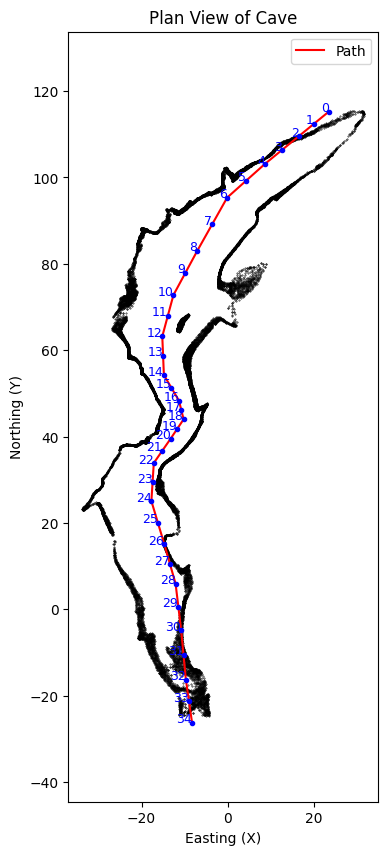

In [12]:
# DISPLAY A ROUGH PLAN VIEW OF THE CAVE
condition = (pts[:,2] > -12) & (pts[:,2] < -11)

ptsplt = pts[condition]

# Create a figure with a specified size
plt.figure(figsize=(4,10))
plt.scatter(ptsplt[:,0], ptsplt[:,1], c = 'black', marker = '.', s = .5)
plt.plot(waypts[:,0], waypts[:,1], 'r-', label = 'Path')

# Waypoint Labels
for i in range(len(waypts)):
    plt.text(waypts[i, 0], waypts[i, 1], f'{i}', fontsize=9, color='blue', ha='right')
    plt.plot(waypts[i, 0], waypts[i, 1], 'b.')

# Set labels
plt.title('Plan View of Cave')
plt.xlabel('Easting (X)')
plt.ylabel('Northing (Y)')
plt.legend()

# Display
plt.axis('equal')
plt.show()

In [14]:
def get_angles(v):
  '''
  Function takes a single 3D point as input and calculates the kappa (about z)
  and omega (about x) rotations necessary to point the y axis through the point.
  '''
  k = -np.arctan2(v[0], v[1])
  o =  np.arctan2(v[2], np.sqrt(v[0]**2 + v[1]**2))
  return o, k

def rotate(pts, o=0, p=0, k=0):
  '''
  Function takes a set of 3D points (columns correspond to x,y,z) and three rotation angles.
  Returns the points with the rotation applied.
  '''
  Ro = np.array([[1,          0,         0],
                 [0,  np.cos(o), np.sin(o)],
                 [0, -np.sin(o), np.cos(o)]])

  Rp = np.array([[np.cos(p),  0,-np.sin(p)],
                 [        0,  1,         0],
                 [np.sin(p),  0, np.cos(p)]])

  Rk = np.array([[ np.cos(k),  np.sin(k), 0],
                 [-np.sin(k),  np.cos(k), 0],
                 [         0,          0, 1]])
  R = Ro @ Rp @ Rk
  new_pts = (R@pts.T).T
  return(new_pts)

def plot_cross_section(pts, title):
  '''
  Function takes points and plots them mapping: x->X, z->Y
  '''
  # Create a figure with a specified size
  plt.figure(figsize=(5, 5))
  plt.scatter(pts[:,0], pts[:,2], c = 'black', marker = '.', s = .5)

  # Set limits
  plt.xlim((-20,20))
  plt.ylim((-20,20))
  plt.title(title)

  # Set labels
  plt.xlabel('X')
  plt.ylabel('Z')

  plt.show()

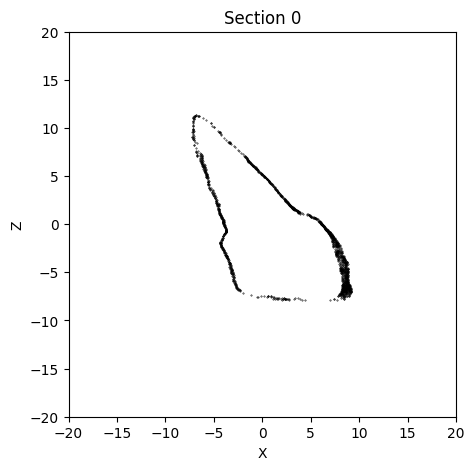

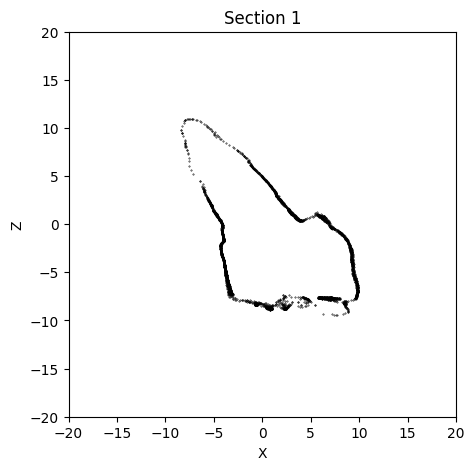

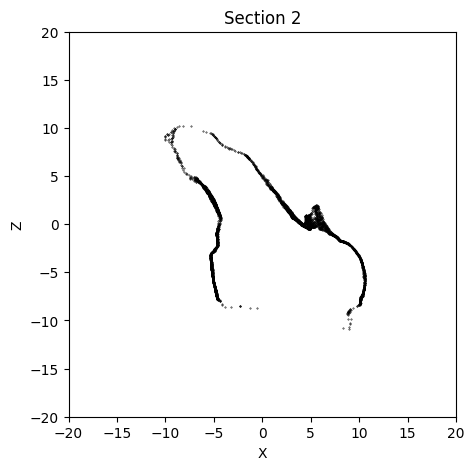

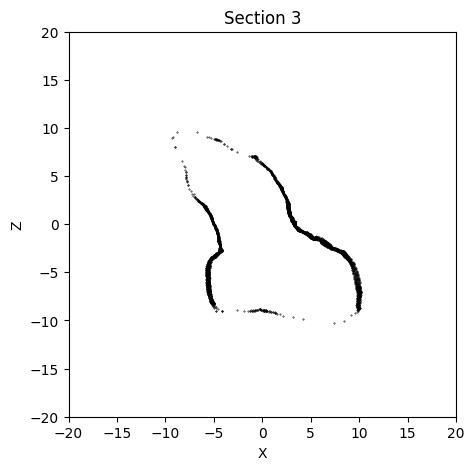

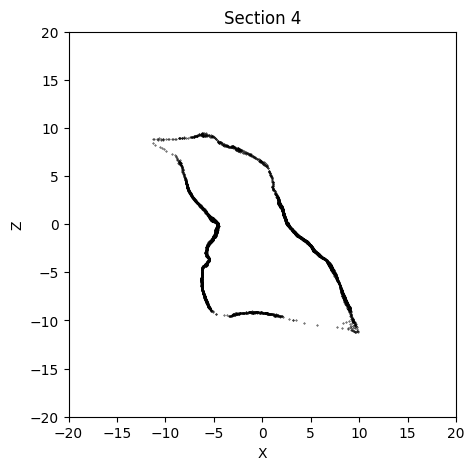

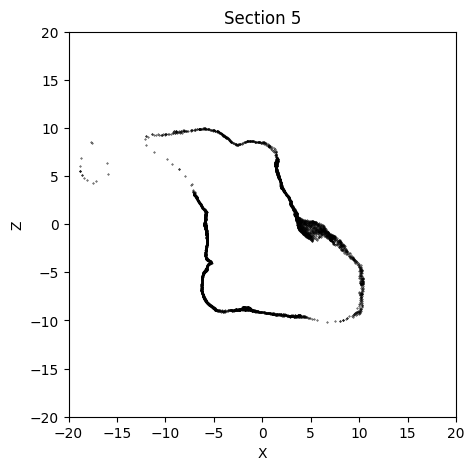

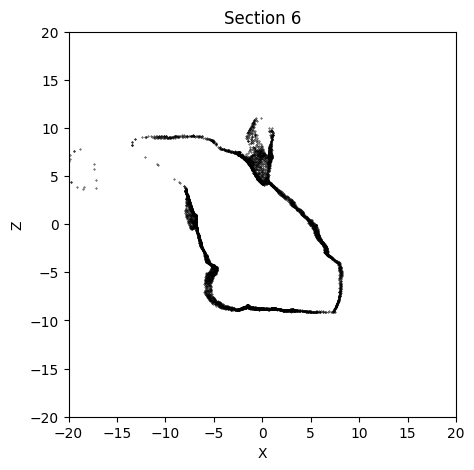

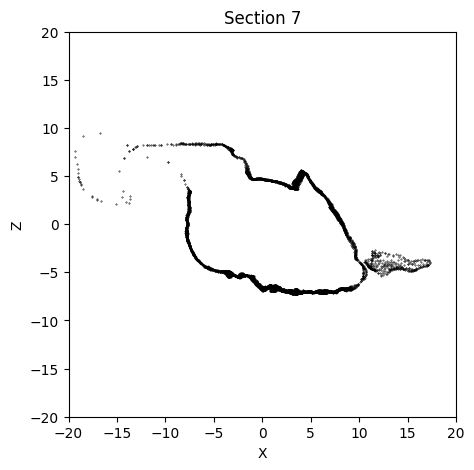

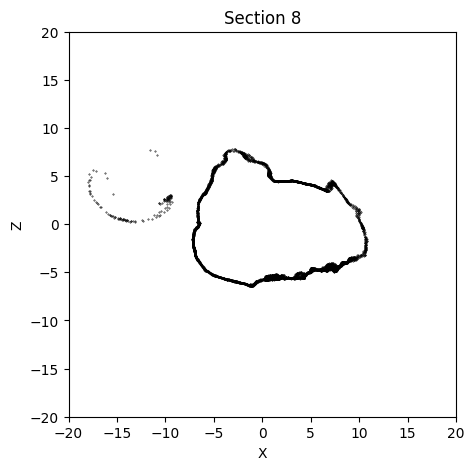

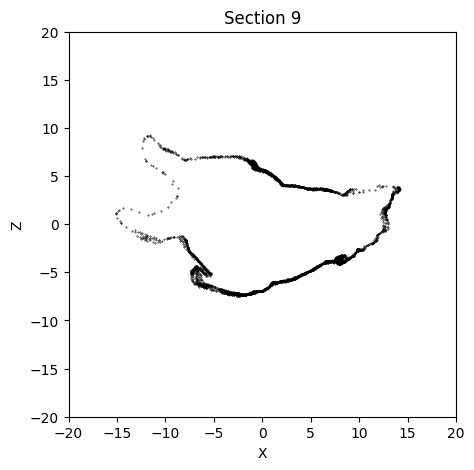

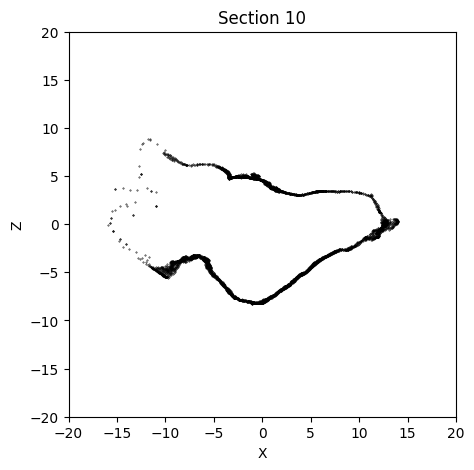

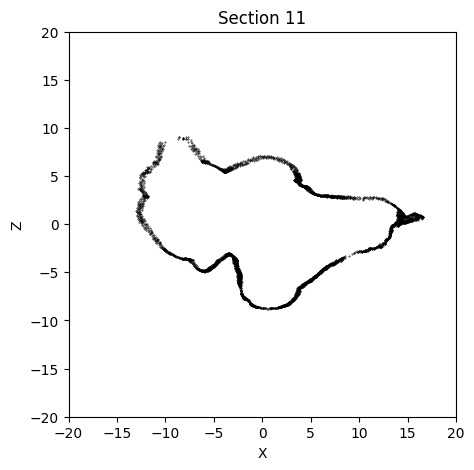

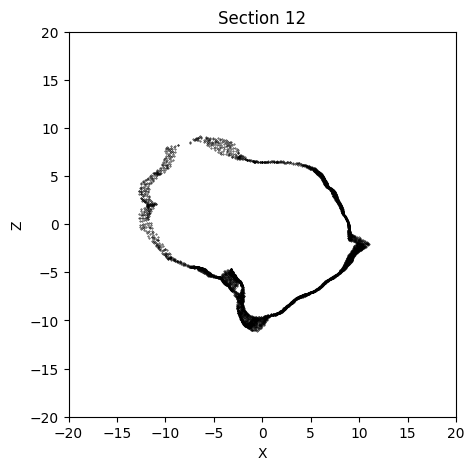

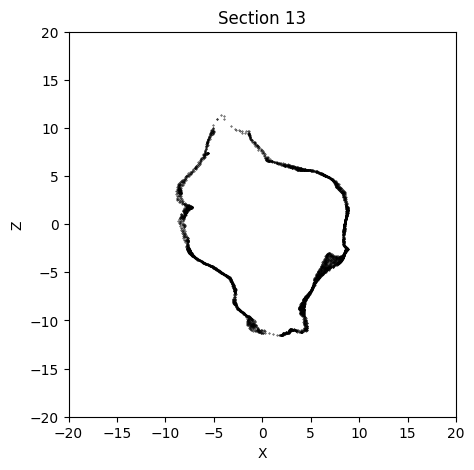

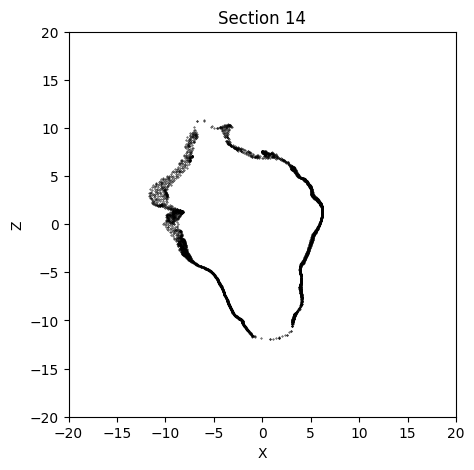

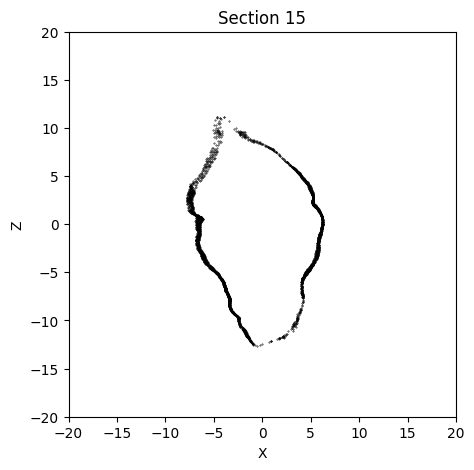

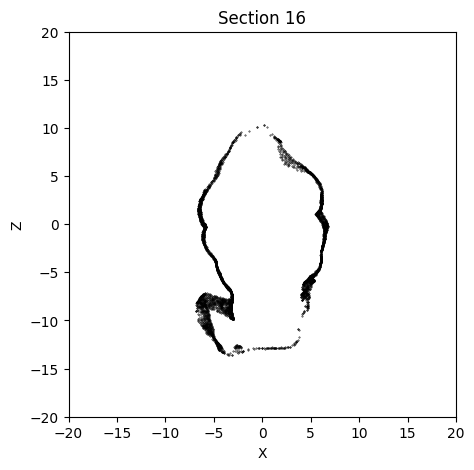

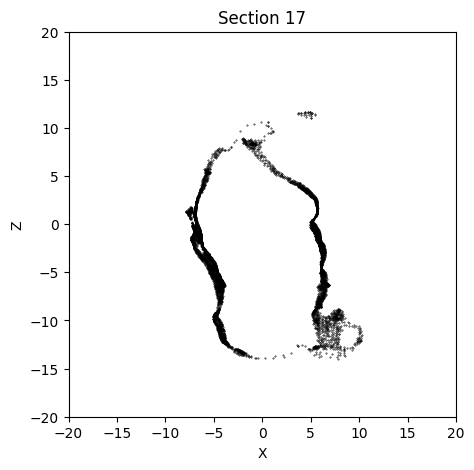

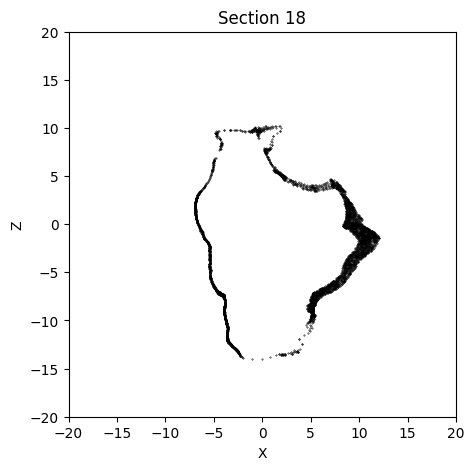

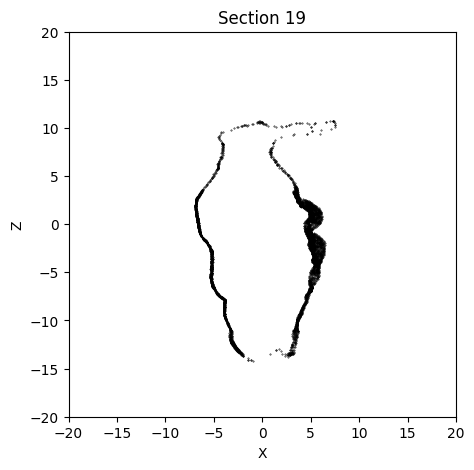

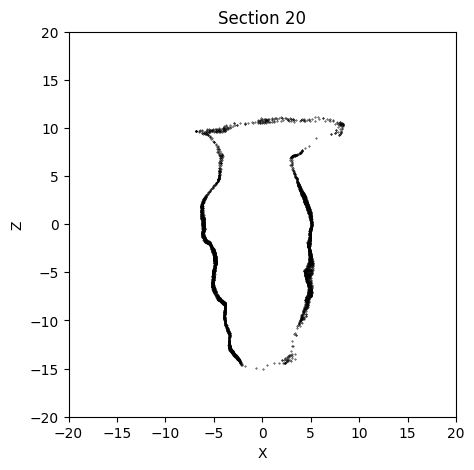

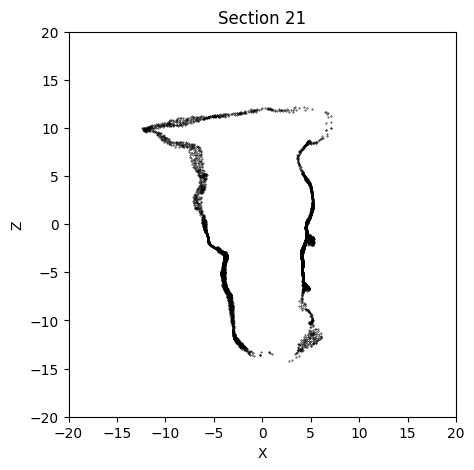

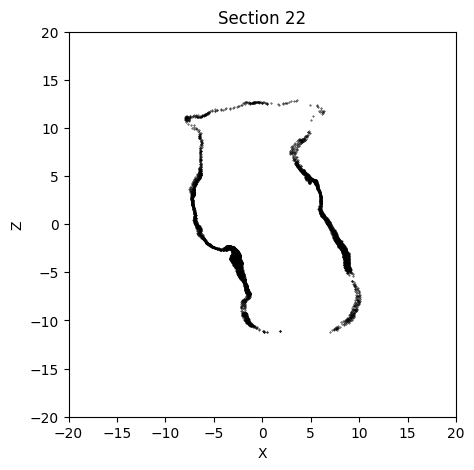

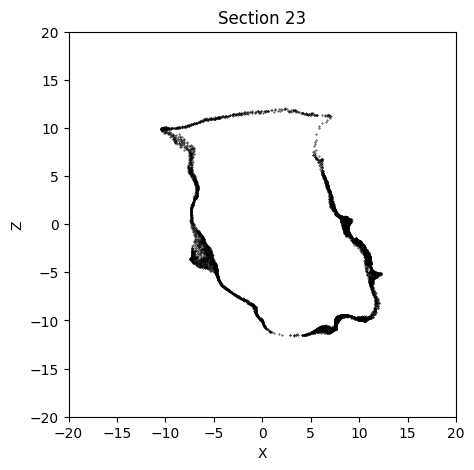

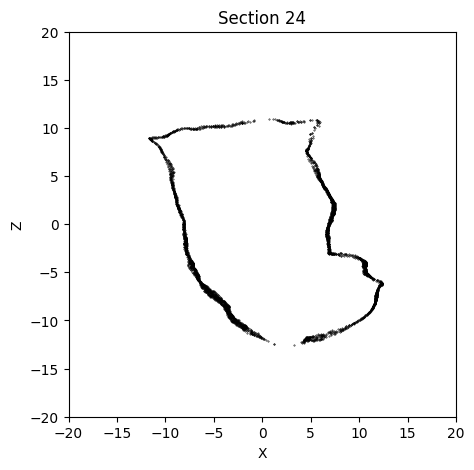

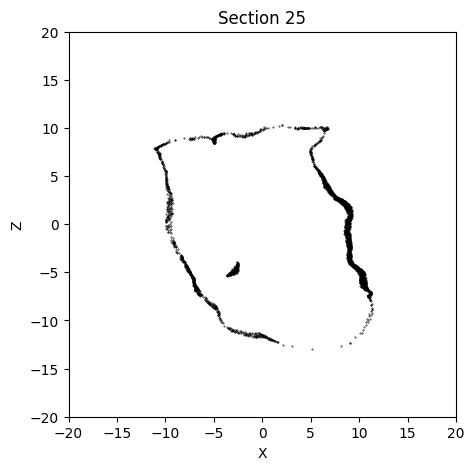

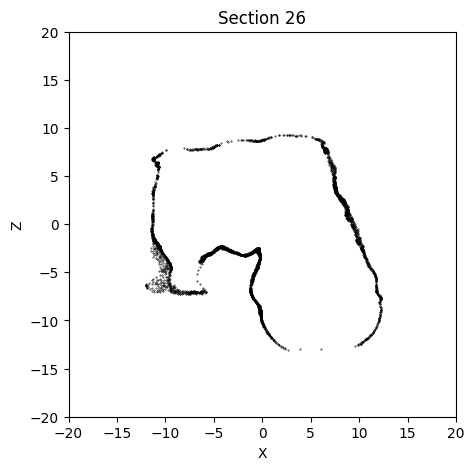

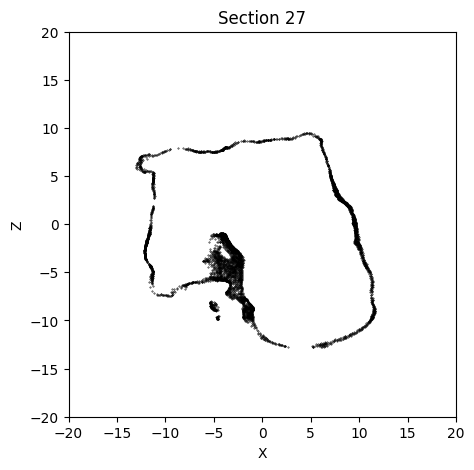

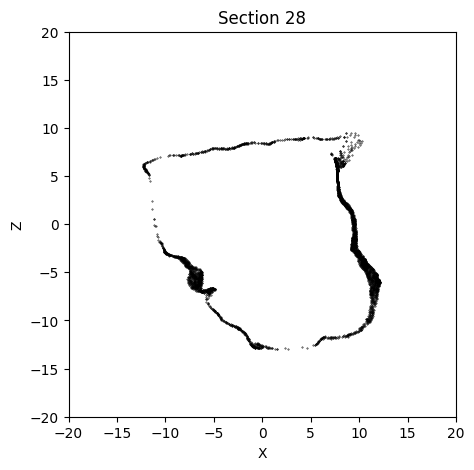

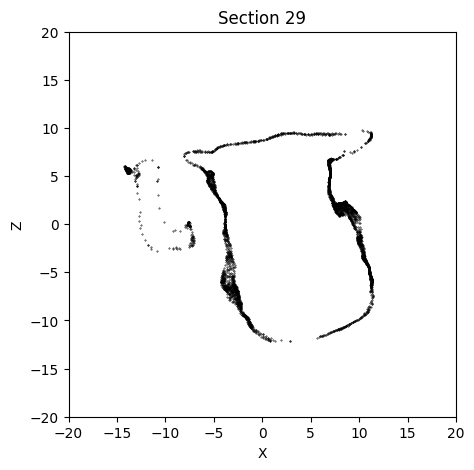

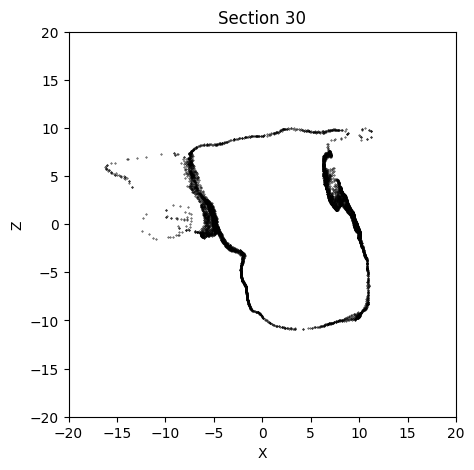

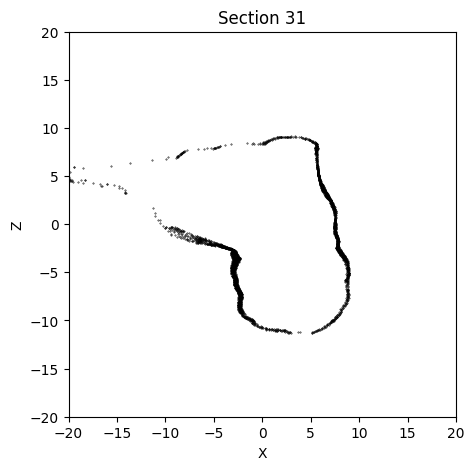

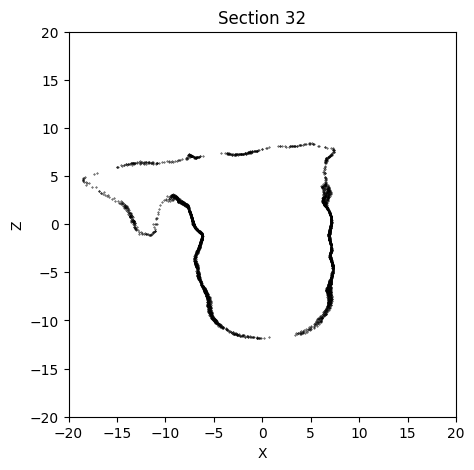

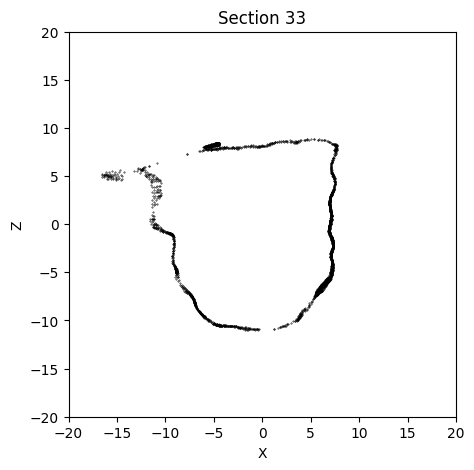

In [15]:
for i, (pt1, pt2) in enumerate(zip(waypts[:-1], waypts[1:])):
  new_pts = pts  - pt1  # Shift
  v = pt2 - pt1         # Pointing Vector
  o,k = get_angles(v)   # Calculate rotation angles
  new_pts = rotate(new_pts, o = o, k = k) #rotate point cloud

  condition = (new_pts[:,1] > -.5) & (new_pts[:,1] < .5) # Get Crossection
  plot_cross_section(new_pts[condition], f'Section {i}') # Plot Crossection